In [4]:
!pip install torch torchvision matplotlib scikit-learn

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
])

In [6]:
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

100.0%


In [7]:
model = models.resnet18(weights='DEFAULT')

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\belag/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [9]:
train_losses = []
train_accs = []

epochs = 5

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total

    train_losses.append(running_loss)
    train_accs.append(acc)

    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.2f}%")

Epoch 1: Loss=841.9579, Accuracy=63.18%
Epoch 2: Loss=612.7050, Accuracy=73.38%
Epoch 3: Loss=542.0230, Accuracy=76.61%
Epoch 4: Loss=482.0499, Accuracy=78.93%
Epoch 5: Loss=437.6113, Accuracy=81.08%


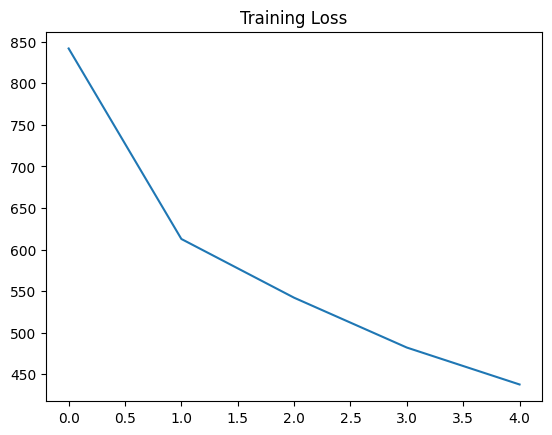

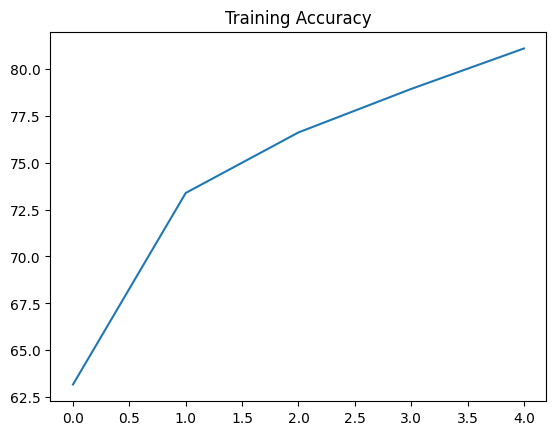

In [10]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

plt.plot(train_accs)
plt.title("Training Accuracy")
plt.show()

In [11]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1000
           1       0.92      0.86      0.89      1000
           2       0.68      0.82      0.74      1000
           3       0.62      0.68      0.65      1000
           4       0.85      0.79      0.82      1000
           5       0.82      0.58      0.68      1000
           6       0.90      0.79      0.84      1000
           7       0.84      0.87      0.85      1000
           8       0.85      0.92      0.88      1000
           9       0.78      0.92      0.84      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



In [12]:
torch.save(
    model.state_dict(),
    "saved_model.pth"
)

In [13]:
model.load_state_dict(
    torch.load("saved_model.pth")
)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

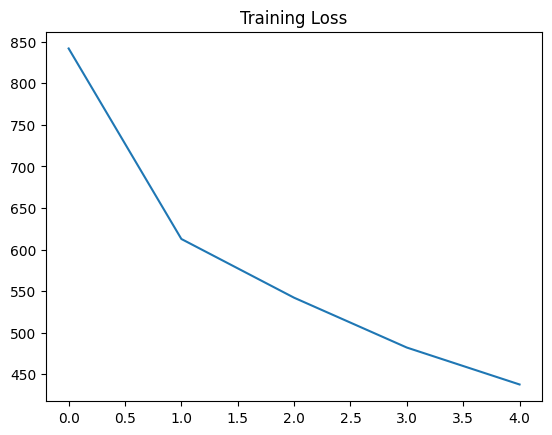

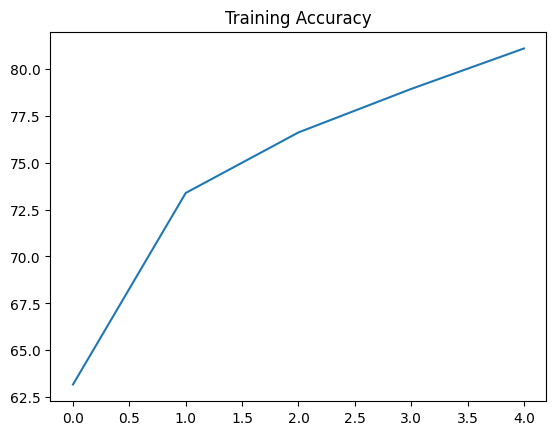

In [14]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

plt.plot(train_accs)
plt.title("Training Accuracy")
plt.show()

In [15]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1000
           1       0.92      0.86      0.89      1000
           2       0.68      0.82      0.74      1000
           3       0.62      0.68      0.65      1000
           4       0.85      0.79      0.82      1000
           5       0.82      0.58      0.68      1000
           6       0.90      0.79      0.84      1000
           7       0.84      0.87      0.85      1000
           8       0.85      0.92      0.88      1000
           9       0.78      0.92      0.84      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000



In [16]:
torch.save(model.state_dict(), "saved_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [17]:
import os
print(os.listdir())

['.cache', '.codex', '.copilot', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.redhat', '.vscode', 'AppData', 'Application Data', 'classification_model.ipynb', 'Contacts', 'Cookies', 'CrossDevice', 'data', 'Desktop', 'Documents', 'Downloads', 'Favorites', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{24303256-1454-11f0-b725-902e164a8254}.TM.blf', 'NTUSER.DAT{24303256-1454-11f0-b725-902e164a8254}.TM.blf.cnpf', 'NTUSER.DAT{24303256-1454-11f0-b725-902e164a8254}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{24303256-1454-11f0-b725-902e164a8254}.TMContainer00000000000000000001.regtrans-ms.cnpf', 'NTUSER.DAT{24303256-1454-11f0-b725-902e164a8254}.TMContainer00000000000000000002.regtrans-ms', 'NTUSER.DAT{24303256-1454-11f0-b725-902e164a8254}.TMContainer00000000000000000002.regtrans-ms.cnpf', 'ntuser.ini', 'OneDrive', 'Pictures', 'ping', 'PrintHood', 

In [18]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1000
           1       0.92      0.86      0.89      1000
           2       0.68      0.82      0.74      1000
           3       0.62      0.68      0.65      1000
           4       0.85      0.79      0.82      1000
           5       0.82      0.58      0.68      1000
           6       0.90      0.79      0.84      1000
           7       0.84      0.87      0.85      1000
           8       0.85      0.92      0.88      1000
           9       0.78      0.92      0.84      1000

    accuracy                           0.80     10000
   macro avg       0.81      0.80      0.80     10000
weighted avg       0.81      0.80      0.80     10000

